# Creating synthetic data with a GAN
To see how a GAN can be trained to create synthetic data, we generate a two dimensional dataset that has 8 disk like clusters around a circle centered at the origin. We will then train a GAN to be able to generate synthetic data.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_gan

#### Generating data
We use a function that creates samples where we input a number of samples, how many clusters we want and some information about the geometry. In our case we just use 8 disks with centers on a circle of radius 5.

In [2]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Generate a dataset of disk-like clusters centered around the origin
    Parameters
    ----------
    n_samples: int
        number of samples to make
    centers : int
        number of clusters to have
    radius : float
        radius of circle where centers of disks like
    std : float
        standard deviation of distance of points in a cluster to the center
    seed : int
        random seed
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32)


In [3]:
X = make_gaussian_mixture()

#### Training the model
We now create instances of the Generator and Discriminator classes and train on the data.

In [4]:
# set seed for reproducibility
torch.manual_seed(42)

In [5]:
G = Generator(
    noise_dim=2,
    num_hidden_layers=2,
    out_dim=2,
    hidden_dims=(128,128),
    hidden_activation=nn.ReLU
)

D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128)
)

In [ ]:
# train the GAN
X_torch = torch.tensor(X)
train_gan(
    X=X_torch,
    G=G,
    D=D,
    epochs=500,
    return_history=False
)

GAN training:   0%|          | 0/500 [00:00<?, ?it/s]

 #### Visualization
 Now we create a synthetic version of the data, and plot both the real and synthetic data on the same axes

In [7]:

@torch.no_grad()
def plot_samples(G, X_real, n=2000, title = None):
    """
    Plot a an equal number of points from the real data set and 
    fake ones generated
    Parameters
    G : Generator
        used to generate fake data
    X_real : np.ndarray
        array of real data points
    n : int
        number of points
    title : str | None
        optional title for plot
    """
    X_fake = G.generate(n).cpu().numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.axis("equal")
    plt.show()


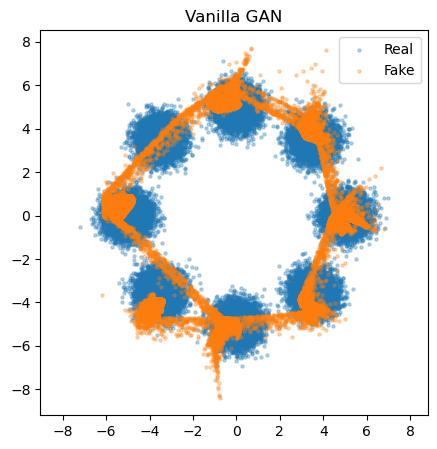

In [9]:
plot_samples(G, X, len(X), "Vanilla GAN")